In [ ]:
import numpy as np
import pandas as pd
from numpy.random import seed, randn, rand
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import sys
print(sys.executable)

### Get MNIST data set

# Using scikit-learn (OpenML)
from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784",version=1,return_X_y=True,as_frame=False)
print(X.shape)  # (70000, 784)
print(y.shape)  # (70000,)


# Using TensorFlow / Keras
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)  # (60000, 28, 28)
print(X_test.shape)   # (10000, 28, 28)


# Using PyTorch
import torch
import torchvision
from torchvision import datasets
mnist = datasets.MNIST(root="./data",train=True,download=True)
print(len(mnist))
print(torch.__version__)
print(torchvision.__version__)

from torchvision.datasets import MNIST


print("Setup complete")

c:\Users\iyke\anaconda3\python.exe
(70000, 784)
(70000,)
(60000, 28, 28)
(10000, 28, 28)
60000
2.12.1+cpu
0.27.1+cpu
Setup complete


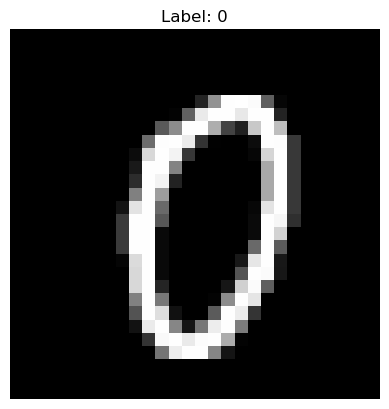

In [4]:
# Using scikit-learn (OpenML)
image = X[1000].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(f"Label: {y[1000]}")
plt.axis("off")
plt.show()

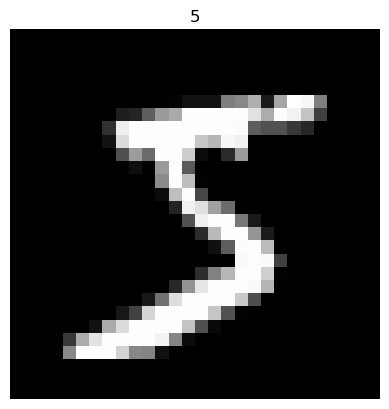

In [5]:
# Using TensorFlow / Keras
plt.imshow(X_train[0], cmap="gray")
plt.title(y_train[0])
plt.axis("off")
plt.show()

0


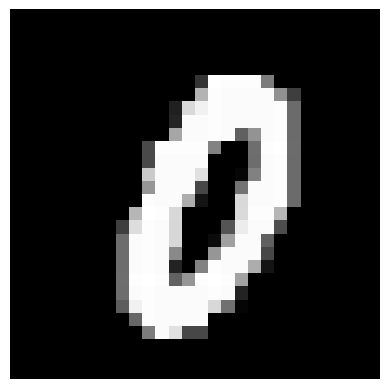

In [6]:
# Using PyTorch
image, label = mnist[34]
print(label)
#image.show() # Saves the image to a temporary file, launches the operating system's default image viewer and opens the image in that viewer
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

# <u>Digit classification</u>


**Goal:Classify handwritten digits ranging from 0 to 9 $\Rightarrow g=$ 10 class classification** 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/1_.png" width="500"/>
</div>

Each data point/image has 28 $\times$ 28 pixels so 784 pixels in total. Each pixel value lies between 0 and 255 with 0 being a fully black pixel and 255 a fully white pixel.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/2_.png" width="500"/>
</div>


In [7]:
# Load MNIST
mnist = MNIST(root="./data",train=True,download=True)

# Create 10x10 grid
rows = 10
cols = 10
img_size = 28

canvas = np.ones((rows * img_size, cols * img_size)) * 255

for i in range(rows):
    for j in range(cols):
        idx = i * cols + j
        image, label = mnist[idx]
        image = np.array(image)
        canvas[i*img_size:(i+1)*img_size,j*img_size:(j+1)*img_size] = image

# Plot with Plotly
fig = px.imshow(canvas,color_continuous_scale="gray",aspect="equal")
fig.update_layout(title="MNIST 10x10 Grid",coloraxis_colorbar_title="Pixel Value")

fig.show()

In [8]:
mnist = MNIST(root="./data",train=True,download=True)

digit_images = {d: [] for d in range(10)}

for image, label in mnist:
    if len(digit_images[label]) < 10:
        digit_images[label].append(np.array(image))

    if all(len(v) == 10 for v in digit_images.values()):
        break

canvas = np.ones((10*28, 10*28)) * 255

for row in range(10):
    for col in range(10):
        img = digit_images[col][row]
        canvas[row*28:(row+1)*28,col*28:(col+1)*28] = img

fig = px.imshow(canvas,color_continuous_scale="gray",aspect="equal")

fig.update_layout(title="MNIST Digits (Columns = 0,...,9)")

fig.show()

### Dataset

$$
\text{Data}=
\begin{bmatrix}
\text{Image 1} \\
\text{Image 2} \\

\vdots \\
\text{Image m} \\
\end{bmatrix}
=
\begin{bmatrix}
x^{(1)} \\
x^{(2)} \\

\vdots \\
x^{(m)}\\
\end{bmatrix} \in \mathbb{R}^{m \times 784}, \quad
x^{(i)} \in \mathbb{R}_{>0}^{784} \text{ for }i=1,\ldots,m
$$

We will work with the transpose of that and we will divide by 255 to only deal with pixel values between 0 and 1.

$$
\text{Data}=
\begin{bmatrix}
\text{Image 1} &
\text{Image 2} &

\ldots &
\text{Image m} \\
\end{bmatrix}
=
\begin{bmatrix}
x^{(1)} &
x^{(2)} &

\ldots &
x^{(m)}\\
\end{bmatrix} \in \mathbb{R}^{784 \times m} \\[2 mm]
x^{(i)} \in \mathbb{R}_{>0}^{784} \text{ for }i=1,\ldots,m
$$

### Neural Network

$$
\hat{y} = y =  \text{Softmax}(W^{(2)}\text{ReLU}(W^{(1)}x + b^{(1)}) + b^{(2)})
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/3_.jpeg" width="600"/>
</div>

- $X$ of shape $(784 \times m) \Rightarrow$ multiple inputs
- $W^{(1)}$ of shape $(10 \times 784)$
- $b^{(1)}$ of shape $(10 \times 1)$
- $W^{(2)}$ of shape $(10 \times 10)$
- $b^{(2)}$ of shape $(10 \times 1)$
- $\text{ReLU}(x)=\max(0,x)$
- $\text{Softmax}(y)=\frac{\exp(y_i)}{\sum_{j=1}^n\exp(y_j)}$ for $y=(y_1,y_2,\ldots,y_n)$ and $i \in \{1,2,\ldots,n\}$



##### Forward pass
- $z^{(0)}=X$ of shape $(784 \times m)$
- $a^{(1)}=W^{(1)}z^{(0)} + b^{(1)}$ of shape $(10 \times m)$
- $z^{(1)}=\sigma(a^{(1)})=\text{ReLU}(a^{(1)})=\max(0,a^{(1)})$ of shape $(10 \times m)$
- $a^{(2)}=W^{(2)}z^{(1)} + b^{(2)}$ of shape $(10 \times m)$
- $z^{(2)}=\text{Softmax}(a^{(2)})=\frac{\exp(a_i^{(2)})}{\sum_{j=0}^9 \exp(a_j^{(2)})}$ of shape $(10 \times m)$
- $y=z^{(2)}$ of shape $(10 \times m)$
- Cross-entropy loss  $L(y,t)=-\frac{1}{m}\sum_{k=1}^m \sum_{i=0}^9 t_{ik} \log\left(y_{ik}\right)$ for multiple observations and $t \in \{0,1\}^{10 \times m}$, i.e. $t=\begin{bmatrix} 1 & 0 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \\ \vdots & \vdots & \vdots  \end{bmatrix}$ where each column is a one-hot encoded vector representing a digit.

---

$$
\frac{\partial L}{\partial y}= -\frac{1}{m} t \odot y^{-1}, \quad y^{-1}=\left[\frac{1}{y_{ik}}\right]
$$


$$
\begin{align*}
\frac{\partial y_i}{\partial a_j^{(2)}}&=\frac{\partial}{\partial a_j^{(2)}}\text{Softmax}(a_j^{(2)})_i\\
&=\frac{\partial}{\partial a_j^{(2)}}\frac{\exp(a_i^{(2)})}{\sum_{k=0}^9 \exp(a_k^{(2)})} \quad \mid S=\sum_{k=0}^9 \exp(a_k^{(2)})  \\
&= \frac{\frac{\partial}{\partial a_j^{(2)}} \exp(a_i^{(2)}) \cdot S -  \exp(a_i^{(2)})  \frac{\partial}{\partial a_j^{(2)}} S}{S^2} \quad \mid \frac{\partial}{\partial a_j^{(2)}} \exp(a_i^{(2)})=\delta_{ij}\exp(a_i^{(2)}) \text{ with } \delta_{ij}=\begin{cases} 1, &i=j \\ 0, &i \neq j \end{cases} \\
&= \frac{\delta_{ij}\exp(a_i^{(2)}) \cdot S -  \exp(a_i^{(2)})  \frac{\partial}{\partial a_j^{(2)}} S}{S^2} \quad \mid \frac{\partial}{\partial a_j^{(2)}} S = \exp(a_j^{(2)}) \\
&= \frac{\delta_{ij}\exp(a_i^{(2)}) \cdot S -  \exp(a_i^{(2)}) \exp(a_j^{(2)})}{S^2} \quad \mid y_i=\frac{\exp(a_i^{(2)})}{S},y_j=\frac{\exp(a_j^{(2)})}{S} \\
&= y_i(\delta_{ij}-y_j) \\
&= \begin{cases} y_i(1-y_i), &i=j \\ -y_iy_j, &i \neq j \end{cases} \\
\Rightarrow 
\frac{\partial y_k}{\partial a_k^{(2)}}&= \text{Diag}(y_k) - y_k(y_k)^\top
\end{align*}
$$


$$
\frac{\partial a^{(2)}}{\partial b^{(2)}}=I_{10}
$$



$$
\frac{\partial a^{(2)}}{\partial z^{(1)}}=W^{(2)}
$$


$$
\begin{align*}
\frac{\partial z_i^{(1)}}{\partial a_i^{(1)}}
&=\frac{\partial}{\partial a_i^{(1)}} \sigma(a_i^{(1)}) \\
&= \begin{cases} 1, &a_i^{(1)}>0 \\ 0, &a_i^{(1)}\leq 0 \end{cases}\\
&=\frac{\partial}{\partial a_i^{(1)}}\text{ReLU}(a_i^{(1)}) \\
\Rightarrow \frac{\partial z^{(1)}}{\partial a^{(1)}}&=1_{a^{(1)} > 0} \in \mathbb{R}^{10 \times m}

\end{align*}
$$

$$
\frac{\partial a^{(1)}}{\partial b^{(1)}} = \mathrm{I}_{10} 
$$


---

### Backward pass

$$
\begin{align*}
\frac{\partial L}{\partial b^{(2)}}&=\underbrace{\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}}_{(y-t)=\delta^{(2)}}\frac{\partial a^{(2)}}{\partial b^{(2)}}=\frac{1}{m} \sum_{k=1}^m \delta_{:,k}^{(2)}  \in \mathbb{R}^{10 \times 1}\\



\frac{\partial L}{\partial W^{(2)}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial W^{(2)}}=\frac{1}{m}\delta^{(2)}(z^{(1)})^\top = \frac{1}{m}\delta^{(2)} \begin{bmatrix} z_0^{(1)} & z_1^{(1)} & \ldots & z_9^{(1)}  \end{bmatrix} \in \mathbb{R}^{10 \times 10} \\


\frac{\partial L}{\partial b^{(1)}}&=\underbrace{\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial z^{(1)}}\frac{\partial z^{(1)}}{\partial a^{(1)}}}_{\delta^{(1)}}\underbrace{\frac{\partial a^{(1)}}{\partial b^{(1)}}}_{I_{10}}\\ &=(W^{(2)})^\top\delta^{(2)} \odot 1_{a^{(1)} > 0}  \\ &= ((W^{(2)})^\top\delta^{(2)}) \odot \begin{bmatrix} 1_{a_{00}^{(1)}>0} &  \ldots & 1_{a_{0m}^{(1)}>0} \\ \vdots &  \ddots & \vdots \\ 1_{a_{90}^{(1)}>0} &  \ldots & 1_{a_{9m}^{(1)}>0}  \end{bmatrix} \\ 
&= \frac{1}{m} \sum_{k=1}^m \delta_{:,k}^{(1)} \in \mathbb{R}^{10 \times 1} \\



\frac{\partial L}{\partial W^{(1)}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial z^{(1)}}\frac{\partial z^{(1)}}{\partial a^{(1)}}\frac{\partial a^{(1)}}{\partial W^{(1)}}=\frac{1}{m} \delta^{(1)} z^{(0)}=\frac{1}{m}\delta^{(1)}X^\top \in \mathbb{R}^{10 \times 784}  \\
\end{align*}
$$


In [ ]:
data = pd.read_csv('Digits_train.csv') # Read dataset
print("Columns: ",data.columns)
print("Shape: ",data.shape)
data.head()

Columns:  Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)
Shape:  (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Convert to numpy
data = np.array(data)

# Shuffle
np.random.shuffle(data)

# One-hot encoded targets
t = np.eye(10)[data[:, 0]].T
print("Shape of t =", t.shape)

# Images
X = data[:, 1:].T / 255.0 # set pixelvalues to range from 0 to 1
print("Shape of X =", X.shape)

_, m = X.shape
print(f"rows={_}, columns=m={m}")

# Train/test split
X_train = X[:, :int(0.8*m)]
y_train = t[:, :int(0.8*m)]

X_test = X[:, int(0.8*m):]
y_test = t[:, int(0.8*m):]

print(X_train.shape) # (784, 33600)
print(y_train.shape) # (10, 33600)
print(X_test.shape) # (784, 8400)
print(y_test.shape) # (10, 8400)

# X_train,X_test, y_train, y_test = train_test_split(X,t,train_size=0.8,random_state=2237,shuffle=True) # with already transposed X and t

Shape of t = (10, 42000)
Shape of X = (784, 42000)
rows=784, columns=42000
(784, 33600)
(10, 33600)
(784, 8400)
(10, 8400)


In [ ]:
seed(2321)   # reproducibility

def initialize_parameters():
    # standard normal random numbers
    W1 = 0.01 * randn(10, 784)
    b1 = np.zeros((10, 1))
    W2 = 0.01 * randn(10, 10)
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2


def ReLU(x):
    return np.maximum(0, x)


def softmax(x):
    expx = np.exp(x - np.max(x, axis=0, keepdims=True))
    return expx / np.sum(expx, axis=0, keepdims=True)


def forward(W1, b1, W2, b2, X):

    a1 = W1 @ X + b1
    z1 = ReLU(a1)

    a2 = W2 @ z1 + b2
    y = softmax(a2)

    return a1, z1, a2, y


def backward(W1, W2, a1, z1, y, X, t):

    m = X.shape[1]

    delta2 = y - t

    dLdW2 = (1/m) * delta2 @ z1.T
    dLdb2 = (1/m) * np.sum(delta2, axis=1, keepdims=True)

    delta1 = (W2.T @ delta2) * (a1 > 0)

    dLdW1 = (1/m) * delta1 @ X.T
    dLdb1 = (1/m) * np.sum(delta1, axis=1, keepdims=True)

    return dLdW1, dLdb1, dLdW2, dLdb2


def update_parameters(W1, b1, W2, b2,
                      dLdW1, dLdb1, dLdW2, dLdb2,
                      lr):

    W1 -= lr * dLdW1
    b1 -= lr * dLdb1

    W2 -= lr * dLdW2
    b2 -= lr * dLdb2

    return W1, b1, W2, b2


def get_predictions(y):
    return np.argmax(y, axis=0)


def get_accuracy(predictions, t):
    labels = np.argmax(t, axis=0)
    return np.mean(predictions == labels)

def gradient_descent(X, t, lr=0.1, iterations=500):
    W1, b1, W2, b2 = initialize_parameters()

    for i in range(iterations):
        a1, z1, a2, y = forward(W1, b1, W2, b2, X)
        dLdW1, dLdb1, dLdW2, dLdb2 = backward(W1, W2, a1, z1, y, X, t)
        W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2,dLdW1, dLdb1,dLdW2, dLdb2,lr)

        if i % 20 == 0:
            print("Iteration number:", i)
            print("Accuracy =", get_accuracy(get_predictions(y), t))

    return W1, b1, W2, b2


def stochastic_gradient_descent(X, t, lr=0.1, epochs=20):

    W1, b1, W2, b2 = initialize_parameters()

    m = X.shape[1]

    for epoch in range(epochs):

        # shuffle the training examples
        permutation = np.random.permutation(m)
        X_shuffled = X[:, permutation]
        t_shuffled = t[:, permutation]

        for i in range(m):

            # one training example
            x = X_shuffled[:, i:i+1]      # shape (784,1)
            target = t_shuffled[:, i:i+1] # shape (10,1)

            a1, z1, a2, y = forward(W1, b1, W2, b2, x)

            dLdW1, dLdb1, dLdW2, dLdb2 = backward(W1, W2, a1, z1, y, x, target)

            W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2,dLdW1, dLdb1,dLdW2, dLdb2,lr)

        # evaluate on the complete training set
        _, _, _, y_train = forward(W1, b1, W2, b2, X)

        print("Epoch:", epoch)
        print("Accuracy =", get_accuracy(get_predictions(y_train), t))

    return W1, b1, W2, b2

Iteration number: 0
Accuracy = 0.09330357142857143
Iteration number: 20
Accuracy = 0.1162202380952381
Iteration number: 40
Accuracy = 0.24678571428571427
Iteration number: 60
Accuracy = 0.3846428571428571
Iteration number: 80
Accuracy = 0.44729166666666664
Iteration number: 100
Accuracy = 0.5679166666666666
Iteration number: 120
Accuracy = 0.6684523809523809
Iteration number: 140
Accuracy = 0.7372916666666667
Iteration number: 160
Accuracy = 0.7777083333333333
Iteration number: 180
Accuracy = 0.8041071428571429
Iteration number: 200
Accuracy = 0.8232142857142857
Iteration number: 220
Accuracy = 0.8370238095238095
Iteration number: 240
Accuracy = 0.8488988095238095
Iteration number: 260
Accuracy = 0.8570535714285714
Iteration number: 280
Accuracy = 0.8628869047619048
Iteration number: 300
Accuracy = 0.8678571428571429
Iteration number: 320
Accuracy = 0.8719345238095239
Iteration number: 340
Accuracy = 0.8751785714285715
Iteration number: 360
Accuracy = 0.8785416666666667
Iteration numbe

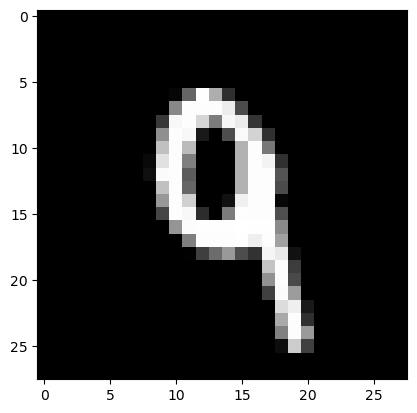

Test accuracy = 0.8901190476190476


In [133]:
W1, b1, W2, b2 = gradient_descent(X_train,y_train,lr=0.1,iterations=500)
#W1, b1, W2, b2 = stochastic_gradient_descent(X_train,y_train,lr=0.1,epochs=50)

val_index = 490
a1, z1, a2, y = forward(W1,b1,W2,b2,X_test[:, val_index, None])

predicted = np.argmax(y)
actual = np.argmax(y_test[:, val_index])

print("Predicted label:", predicted)
print("Actual label:", actual)

image = X_test[:, val_index].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.show()

a1_test, z1_test, a2_test, y_test_pred = forward(W1, b1, W2, b2, X_test)
test_acc = get_accuracy(get_predictions(y_test_pred),y_test)
print("Test accuracy =", test_acc)

Epoch: 0
Accuracy = 0.4920535714285714
Epoch: 1
Accuracy = 0.5777678571428572
Epoch: 2
Accuracy = 0.5521130952380953
Epoch: 3
Accuracy = 0.625
Epoch: 4
Accuracy = 0.6091071428571428
Epoch: 5
Accuracy = 0.4729761904761905
Epoch: 6
Accuracy = 0.5386904761904762
Epoch: 7
Accuracy = 0.5042857142857143
Epoch: 8
Accuracy = 0.5541964285714286
Epoch: 9
Accuracy = 0.4384523809523809
Epoch: 10
Accuracy = 0.4919047619047619
Epoch: 11
Accuracy = 0.4619642857142857
Epoch: 12
Accuracy = 0.5422023809523809
Epoch: 13
Accuracy = 0.5654166666666667
Epoch: 14
Accuracy = 0.5062797619047619
Epoch: 15
Accuracy = 0.552797619047619
Epoch: 16
Accuracy = 0.5286309523809524
Epoch: 17
Accuracy = 0.486875
Epoch: 18
Accuracy = 0.485
Epoch: 19
Accuracy = 0.49488095238095237
Epoch: 20
Accuracy = 0.5336309523809524
Epoch: 21
Accuracy = 0.5258928571428572
Epoch: 22
Accuracy = 0.5129464285714286
Epoch: 23
Accuracy = 0.5119642857142858
Epoch: 24
Accuracy = 0.5555654761904761
Epoch: 25
Accuracy = 0.5542559523809524
Epoch:

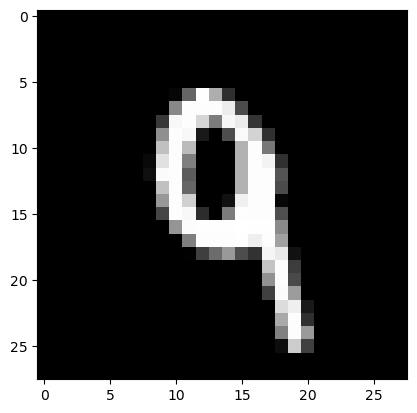

Test accuracy = 0.47095238095238096


In [132]:
#W1, b1, W2, b2 = gradient_descent(X_train,y_train,lr=0.1,iterations=500)
W1, b1, W2, b2 = stochastic_gradient_descent(X_train,y_train,lr=0.1,epochs=50)

val_index = 490
a1, z1, a2, y = forward(W1,b1,W2,b2,X_test[:, val_index, None])

predicted = np.argmax(y)
actual = np.argmax(y_test[:, val_index])

print("Predicted label:", predicted)
print("Actual label:", actual)

image = X_test[:, val_index].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.show()

a1_test, z1_test, a2_test, y_test_pred = forward(W1, b1, W2, b2, X_test)
test_acc = get_accuracy(get_predictions(y_test_pred),y_test)
print("Test accuracy =", test_acc)

Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.9527083333333334
Training accuracy = 0.952

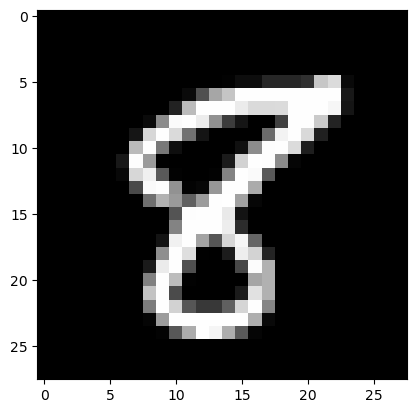

In [134]:
# X_train: (784, 33600)
# y_train: (10, 33600)

# MLPClassifier expects rows = samples and columns = features so transpose the matrices
X_train_sklearn = X_train.T # (33600, 784)
X_test_sklearn = X_test.T # (8400, 784)

# convert one-hot encoding to labels
Y_train = np.argmax(y_train, axis=0)
Y_test = np.argmax(y_test, axis=0)

iter = 500
mlp = MLPClassifier(
    hidden_layer_sizes=(10,), # one hidden layer with 10 neurons
    activation="relu",
    solver="sgd", # stochastic gradient descent
    learning_rate_init=0.1,
    max_iter=iter,
    random_state=2321,
    verbose=False) # if verbose=True then mlp.fit(...) automatically prints the Iterations and the losses

mlp.fit(X_train_sklearn, Y_train)
train_predictions = mlp.predict(X_train_sklearn)
train_accuracy = accuracy_score(Y_train, train_predictions)
for _ in range(iter):
    if _ % 10 == 0:
        print("Training accuracy =", train_accuracy) # shoudl be higher than Validation accuracy
   

test_predictions = mlp.predict(X_test_sklearn)
test_accuracy = accuracy_score(Y_test, test_predictions)
for _ in range(iter):
    if _ % 10 == 0:
        print("Validation accuracy =", test_accuracy)


val_index = 560

prediction = mlp.predict(X_test_sklearn[val_index].reshape(1, -1))[0]

actual = Y_test[val_index]

print("Predicted label:", prediction)
print("Actual label:", actual)

image = X_test_sklearn[val_index].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.show()